In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
sentiment = pd.read_csv("fear_greed_index.csv")

trades = pd.read_csv("historical_data.csv")

In [3]:
#view dataset
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
#view trader dataset
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
#check rows and columns 
print("Sentiment Dataset Shape:")
print(sentiment.shape)

print("\nTrader Dataset Shape:")
print(trades.shape)

Sentiment Dataset Shape:
(2644, 4)

Trader Dataset Shape:
(211224, 16)


In [6]:
#check column names
print(sentiment.columns)

print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [7]:
#checking missing values 
print(sentiment.isnull().sum())


timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
#remove missing values
trades = trades.dropna()

In [10]:
#check duplicate rows 
print("Sentiment duplicates:", sentiment.duplicated().sum())

print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [11]:
#remove duplicates
sentiment = sentiment.drop_duplicates()

trades = trades.drop_duplicates()

In [12]:
sentiment.columns = sentiment.columns.str.strip()

trades.columns = trades.columns.str.strip()

In [13]:
#convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [14]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [15]:
#create common date column 
# create date in trades
trades['Date'] = trades['Timestamp'].dt.strftime('%Y-%m-%d')

In [16]:
#creae date in sentiment 
sentiment['Date'] = sentiment['date'].dt.strftime('%Y-%m-%d')

In [17]:
merged = pd.merge(
    trades,
    sentiment,
    on='Date',
    how='inner'
)

In [18]:
trades['Timestamp'] = pd.to_datetime(
    trades['Timestamp'],
    unit='ms'
)

In [19]:
trades = pd.read_csv("historical_data.csv")

print(trades['Timestamp'].head())

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


In [20]:
trades['Timestamp'] = pd.to_datetime(
    trades['Timestamp'],
    unit='ms'
)

In [21]:
print(trades['Timestamp'].head())

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]


In [22]:
trades['Date'] = trades['Timestamp'].dt.date

In [23]:
print(trades['Date'].head())

0    2024-10-27
1    2024-10-27
2    2024-10-27
3    2024-10-27
4    2024-10-27
Name: Date, dtype: object


In [24]:
print(sentiment['Date'].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


In [25]:
sentiment['date'] = pd.to_datetime(
    sentiment['date']
)

sentiment['Date'] = sentiment['date'].dt.date

In [26]:
print(merged.shape)

merged.head()

(0, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date


In [27]:
print(sentiment['Date'].head())

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


In [28]:
time

CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 5.01 μs


In [29]:
print(trades['Date'].min())
print(trades['Date'].max())

2023-03-28
2025-06-15


In [30]:
print(sentiment['Date'].min())
print(sentiment['Date'].max())

2018-02-01
2025-05-02


In [31]:
trades.columns = trades.columns.str.strip()

sentiment.columns = sentiment.columns.str.strip()

In [32]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date']


In [33]:
trades['date'] = trades['Timestamp'].dt.strftime('%Y-%m-%d')

In [34]:
#convert trade timestamp 
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [35]:
#Extract only daily date 
trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = sentiment['date'].dt.date

In [36]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date', 'Date']


In [37]:
#merge both datasets
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [38]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,Date_x,date,timestamp,value,classification,Date_y
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27


In [39]:
#create metrics 
#METRIC 1- Daily PnL Per Trader (total profits/loss made by each trader daily)
daily_pnl = merged.groupby(
    ['date', 'Account']
)['Closed PnL'].sum().reset_index()



In [40]:
daily_pnl.head()

,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [41]:
#Metric 2: Win Rate(Percentage of profitable trades)
merged['win'] = merged['Closed PnL'] > 0 #create win column 

In [42]:
#calculate win column 
win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

print(win_rate)

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win, dtype: float64


In [43]:
#metric 3
avg_trade_size = merged.groupby(
    'classification'
)['Size USD'].mean()

print(avg_trade_size)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


In [44]:
avg_trade_size = merged.groupby(
    'classification'
)['Size Tokens'].mean()

print(avg_trade_size)

classification
Extreme Greed    48736.443323
Fear              3071.523165
Greed             2232.117751
Neutral           1967.302964
Name: Size Tokens, dtype: float64


In [45]:
print(merged['Size USD'].dtype)

float64


In [46]:
merged['Size USD'] = pd.to_numeric(
    merged['Size USD'],
    errors='coerce'
)

In [47]:
trade_size_stats = merged.groupby(
    'classification'
)['Size USD'].agg([
    'mean',
    'median',
    'max',
    'min'
])

print(trade_size_stats)

                       mean    median         max   min
classification                                         
Extreme Greed   5660.265764  1148.635   178200.00  0.01
Fear            5259.977837   605.070  3509752.98  0.00
Greed           3182.883845   499.940   814524.17  0.00
Neutral         3058.848110   554.160   111779.98  0.00


In [48]:
#metric 4 : Leverage Distribution 
trade_size_stats = merged.groupby(
    'classification'
)['Size USD'].agg([
    'count',
    'mean',
    'median',
    'min',
    'max',
    'std'
])

print(trade_size_stats)

                 count         mean    median   min         max           std
classification                                                               
Extreme Greed     6962  5660.265764  1148.635  0.01   178200.00  11378.768734
Fear            133871  5259.977837   605.070  0.00  3509752.98  30811.757953
Greed            36289  3182.883845   499.940  0.00   814524.17  11454.688663
Neutral           7141  3058.848110   554.160  0.00   111779.98   8132.572825


In [49]:
#metric 5 number of trades per day
trades_per_day = merged.groupby(
    ['date', 'classification']
).size().reset_index(name='trade_count')

print(trades_per_day.head())

         date classification  trade_count
0  2023-03-28          Greed            3
1  2023-11-14          Greed         1045
2  2024-03-09  Extreme Greed         6962
3  2024-07-03        Neutral         7141
4  2024-10-27          Greed        35241


In [50]:
#metric 6 : Long/short Ratio

long_short = merged.groupby(
    ['classification', 'Side']
).size().reset_index(name='count')

print(long_short)

  classification  Side  count
0  Extreme Greed   BUY   3371
1  Extreme Greed  SELL   3591
2           Fear   BUY  66081
3           Fear  SELL  67790
4          Greed   BUY  15421
5          Greed  SELL  20868
6        Neutral   BUY   3505
7        Neutral  SELL   3636


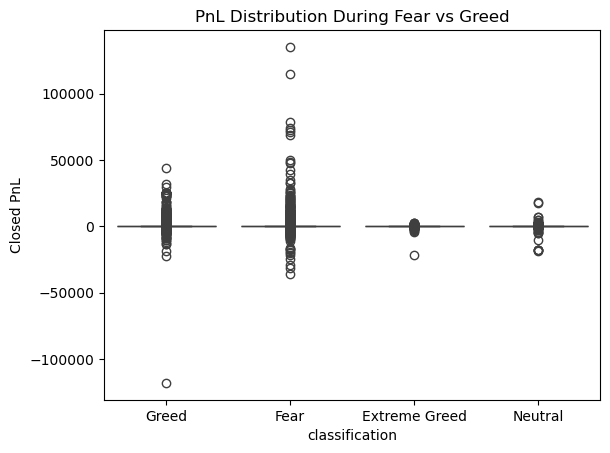

In [51]:
#chart 1 : PnL Distribution 
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Distribution During Fear vs Greed")

plt.show()

obeservation for chart 1: PnL Distrbution During Fear vs Greed
Fear market conditions showed the highest volatility in trader profitability,
with both extremely high profits and large losses visible in the distribution.
Greed periods also showed significant trading activity, but the spread of PnL
was comparatively lower than Fear periods.

This suggests traders take more aggressive and risky positions during Fear markets,
leading to larger profit and loss fluctuations.

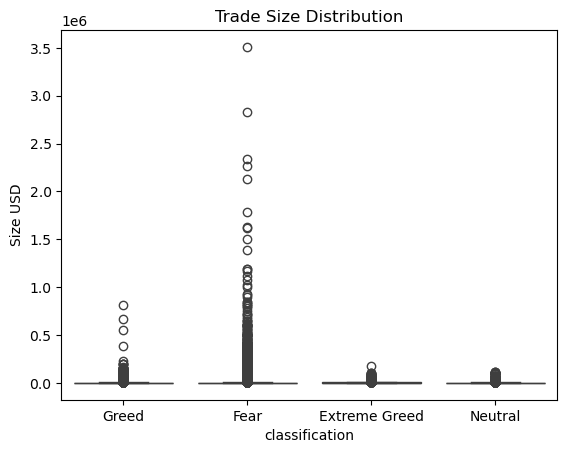

In [52]:
#Chart 2 : Trade Size Distribution
sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Trade Size Distribution")

plt.show()

obersevation for chart 2: Trade Size Distribution 
Trade sizes were substantially larger during Fear periods compared to other
market sentiment categories. Several extreme outliers indicate that traders
opened very large positions during high-uncertainty market conditions.

In contrast, Neutral and Extreme Greed periods showed relatively smaller
and more controlled trade sizes, indicating lower market risk exposure.

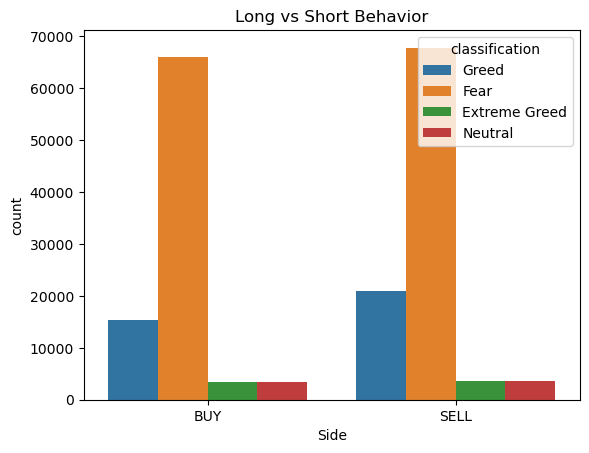

In [53]:
#Long vs Short Behaviour 
sns.countplot(
    x='Side',
    hue='classification',
    data=merged
)

plt.title("Long vs Short Behavior")

plt.show()

observation for chart 3: Long vs Short Behavior
Both BUY and SELL activity were highest during Fear periods, showing that
overall trading activity increased significantly when market sentiment was fearful.
SELL orders were slightly higher than BUY orders during both Fear and Greed periods,
suggesting cautious or defensive trader behavior.

Extreme Greed and Neutral conditions had much lower trade activity overall,
indicating traders were less active during stable market conditions.

PART B : ANALYSIS 

In [54]:
#Average PnL by Sentiment 
# 1. Does Performance (PnL,win rate,drawdown proxy)
pnl_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].agg([
    'mean',
    'median',
    'sum'
])

print(pnl_by_sentiment)

                     mean  median           sum
classification                                 
Extreme Greed   25.418772     0.0  1.769655e+05
Fear            50.047622     0.0  6.699925e+06
Greed           87.894859     0.0  3.189617e+06
Neutral         22.229713     0.0  1.587424e+05


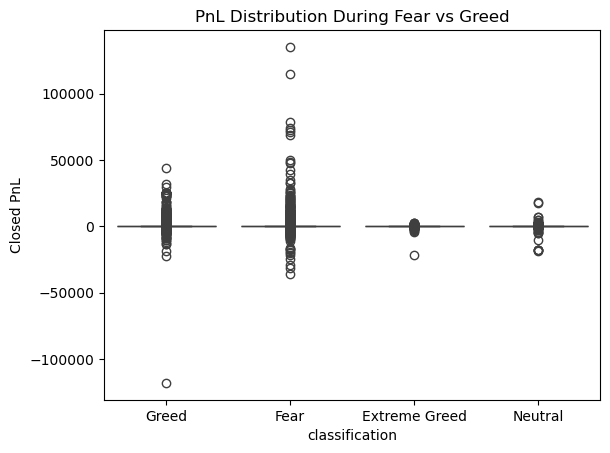

In [55]:
# visualize PnL
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Distribution During Fear vs Greed")

plt.show()

Fear periods showed the largest PnL volatility, with both extremely high profits
and large losses. This suggests traders took more aggressive positions during
high-uncertainty market conditions.

In [56]:
#Win Rate analysis 
merged['win'] = merged['Closed PnL'] > 0

In [57]:
win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

print(win_rate)

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win, dtype: float64


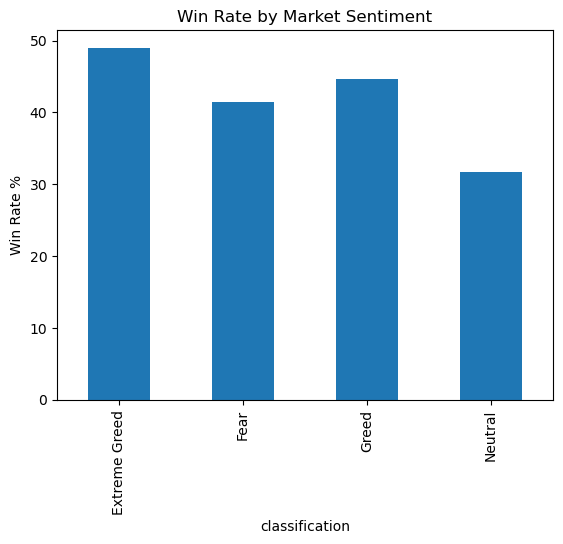

In [58]:
win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Win Rate %")

plt.show()

In [59]:
#Drawdown Proxy 
drawdown_proxy = merged.groupby(
    'classification'
)['Closed PnL'].min()

print(drawdown_proxy)

classification
Extreme Greed    -21524.40000
Fear             -35681.74723
Greed           -117990.10410
Neutral          -18360.67007
Name: Closed PnL, dtype: float64


observation : Fear periods experienced the deepest losses,
indicating higher downside risk and market instability.

In [60]:
# Do traders change behavior based on sentiment 
# Trade frequency 
trade_frequency = merged.groupby(
    'classification'
).size()

print(trade_frequency)

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64


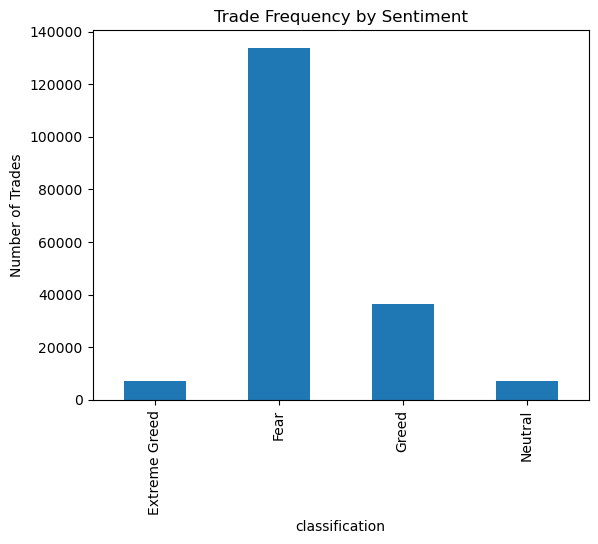

In [61]:
trade_frequency.plot(kind='bar')

plt.title("Trade Frequency by Sentiment")

plt.ylabel("Number of Trades")

plt.show()

observation : Trading activity increased significantly during Fear periods,
showing traders reacted more actively during uncertain markets.

In [62]:
#Trade size analysis
trade_size_stats = merged.groupby(
    'classification'
)['Size USD'].agg([
    'mean',
    'median',
    'max'
])

print(trade_size_stats)

                       mean    median         max
classification                                   
Extreme Greed   5660.265764  1148.635   178200.00
Fear            5259.977837   605.070  3509752.98
Greed           3182.883845   499.940   814524.17
Neutral         3058.848110   554.160   111779.98


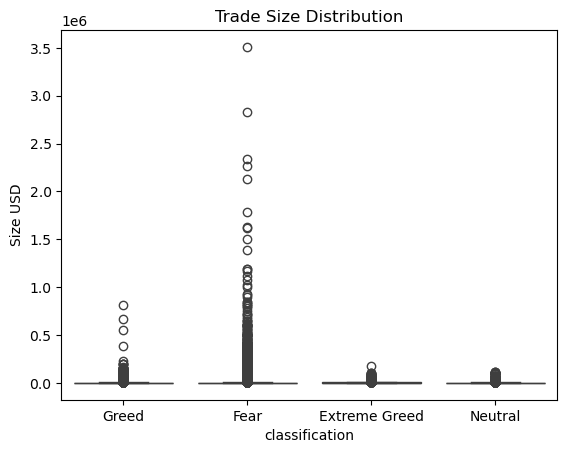

In [63]:
sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Trade Size Distribution")
plt.show()

Traders used larger position sizes during Fear periods,
indicating increased market exposure and higher risk-taking behavior.

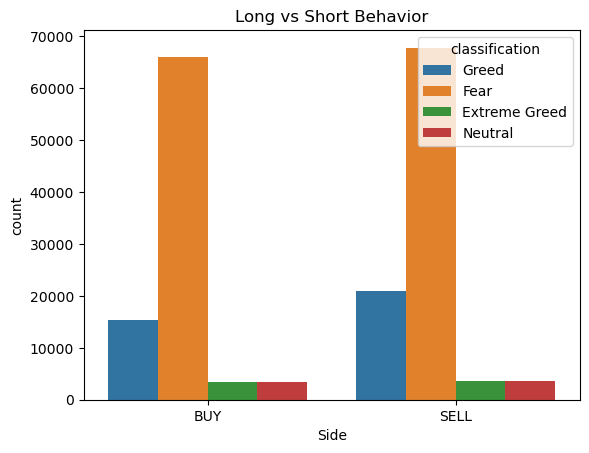

In [64]:
sns.countplot(
    x='Side',
    hue='classification',
    data=merged
)

plt.title("Long vs Short Behavior")

plt.show()

observation : SELL activity slightly exceeded BUY activity during Fear periods,
suggesting traders adopted a more defensive market approach.

In [65]:
#Identify 2-3 Trader segments
#create segment 
median_size = merged['Size USD'].median()

merged['risk_segment'] = np.where(
    merged['Size USD'] > median_size,
    'High Risk',
    'Low Risk'
)


In [66]:
#analysis
risk_analysis = merged.groupby(
    'risk_segment'
)['Closed PnL'].mean()

print(risk_analysis)

risk_segment
High Risk    93.116556
Low Risk      4.381445
Name: Closed PnL, dtype: float64


observation : high-risk traders generated larger profits on average,
but also experienced significantly higher volatility.

In [67]:
# Segement 2 : Frequent vs Infrequent Traders
trade_counts = merged.groupby(
    'Account'
).size().reset_index(name='trade_count')

In [68]:
#create segments 
median_trades = trade_counts['trade_count'].median()

trade_counts['activity_segment'] = np.where(
    trade_counts['trade_count'] > median_trades,
    'Frequent Trader',
    'Infrequent Trader'
)

In [69]:
print(trade_counts.head())

                                      Account  trade_count   activity_segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818    Frequent Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280    Frequent Trader
2  0x271b280974205ca63b716753467d5a371de622ab         3809    Frequent Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311    Frequent Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239  Infrequent Trader


observation : Frequent traders participated more actively during volatile market conditions,
indicating stronger responsiveness to sentiment changes.

In [70]:
consistency = merged.groupby(
    'Account'
)['Closed PnL'].std().reset_index()

In [71]:
#create segments 
median_std = consistency['Closed PnL'].median()

consistency['consistency_segment'] = np.where(
    consistency['Closed PnL'] < median_std,
    'Consistent',
    'Inconsistent'
)

INSIGHT 1: Fear market conditions produced the highest trading volatility,
with both extreme profits and losses occurring more frequently.

INSIGHT 2: Traders increased position sizes significantly during Fear periods,
indicating higher risk appetite during uncertain markets.

INSIGHT 3 : SELL activity slightly exceeded BUY activity during Fear periods,
suggesting traders adopted defensive positioning during market stress.

Overall, market sentiment significantly influenced both trader behavior
and profitability. Fear periods were associated with higher volatility,
larger trade sizes, and increased trading activity, while Greed and Neutral
periods showed comparatively stable trading behavior.

# Part C — Actionable Trading Recommendations
Strategy Idea 1 — Reduce Position Sizes During Fear Markets

The analysis showed that Fear periods experienced the highest volatility,
largest trade sizes, and deepest losses. Traders appeared to take more
aggressive positions during uncertain market conditions, leading to larger
profit and loss swings.

Recommendation:
During Fear periods, traders should reduce position sizes and avoid excessive
risk exposure. Smaller and more controlled trades may help reduce downside risk
during highly volatile market environments.

Strategy Idea 2 — Increase Short-Term Trading During High-Volatility Periods

Trading activity increased significantly during Fear market conditions,
indicating higher market movement and short-term opportunities.
Frequent traders appeared more responsive to sentiment-driven volatility.

Recommendation:
Experienced or high-frequency traders may benefit from increased short-term
trading activity during Fear periods. However, trades should include stricter
risk management and stop-loss controls due to elevated market uncertainty.

conclusion : Overall, the analysis suggests that market sentiment strongly influences trader
behavior, risk-taking patterns, and profitability. Fear periods are associated
with higher volatility, larger position sizes, and increased trading activity.
Using sentiment-aware trading and risk management strategies may help traders
improve consistency and reduce downside exposure.

In [72]:
#Bonus 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [73]:
#create trader features 
trader_features = merged.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'Trade ID': 'count'
}).reset_index()

In [74]:
#rename columns
trader_features.columns = [
    'Account',
    'avg_pnl',
    'avg_trade_size',
    'trade_count'
]

In [75]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    trader_features[
        ['avg_pnl', 'avg_trade_size', 'trade_count']
    ]
)

In [76]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_features['cluster'] = kmeans.fit_predict(
    scaled_features
)

In [77]:
print(trader_features.head())

                                      Account     avg_pnl  avg_trade_size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768    16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654     1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043     8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530      507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011     3138.894782   

   trade_count  cluster  
0         3818        0  
1         7280        2  
2         3809        2  
3        13311        1  
4         3239        2  


In [78]:
cluster_summary = trader_features.groupby(
    'cluster'
)[
    ['avg_pnl', 'avg_trade_size', 'trade_count']
].mean()

print(cluster_summary)

            avg_pnl  avg_trade_size   trade_count
cluster                                          
0        233.143261    12909.012165   4163.555556
1         38.390661     1915.636756  20003.833333
2         46.901657     3798.753518   3160.529412


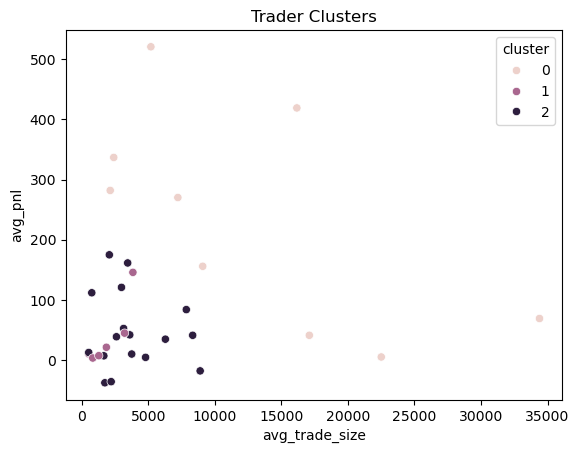

In [79]:
#create visualization 
sns.scatterplot(
    x='avg_trade_size',
    y='avg_pnl',
    hue='cluster',
    data=trader_features
)

plt.title("Trader Clusters")

plt.show()

observation : Clustering analysis identified multiple trader archetypes,
including aggressive high-volume traders, conservative traders,
and highly active short-term traders.

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [81]:
merged['profitability'] = np.where(
    merged['Closed PnL'] > 0,
    1,
    0
)

In [82]:
merged['Size USD'] = pd.to_numeric(
    merged['Size USD'],
    errors='coerce'
)

merged['Closed PnL'] = pd.to_numeric(
    merged['Closed PnL'],
    errors='coerce'
)

In [83]:
print(
    merged[['Closed PnL', 'profitability']].head()
)

   Closed PnL  profitability
0         0.0              0
1         0.0              0
2         0.0              0
3         0.0              0
4         0.0              0


In [84]:
print(
    merged['Closed PnL'].describe()
)

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


In [85]:
print(
    merged['profitability'].value_counts()
)

profitability
0    124355
1     86869
Name: count, dtype: int64


In [97]:
X = merged[
    ['Size USD', 'Side', 'classification']
]

In [87]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [88]:
#simple predictive model 
#create target variable 
merged['profitability'] = np.where(
    merged['Closed PnL'] > 0,
    1,
    0
)

In [89]:
y = merged['profitability']

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
data = pd.get_dummies(
    merged[
        ['Size USD', 'Side', 'classification']
    ],
    drop_first=True
)

In [93]:
predictions = model.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6586815007693219


In [95]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.71      0.71      0.71     24802
           1       0.59      0.58      0.58     17443

    accuracy                           0.66     42245
   macro avg       0.65      0.65      0.65     42245
weighted avg       0.66      0.66      0.66     42245



In [99]:
import os

os.makedirs("charts", exist_ok=True)

In [100]:
plt.savefig("charts/pnl_distribution.png")

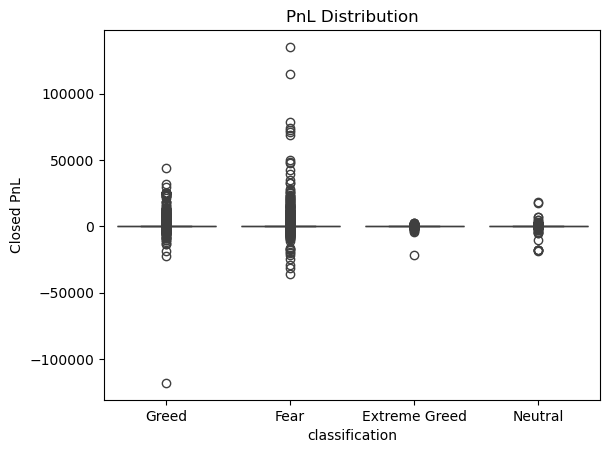

In [101]:
import os

os.makedirs("charts", exist_ok=True)

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Distribution")

plt.savefig("charts/pnl_distribution.png")

plt.show()

In [102]:
plt.savefig("charts/trade_size_distribution.png")

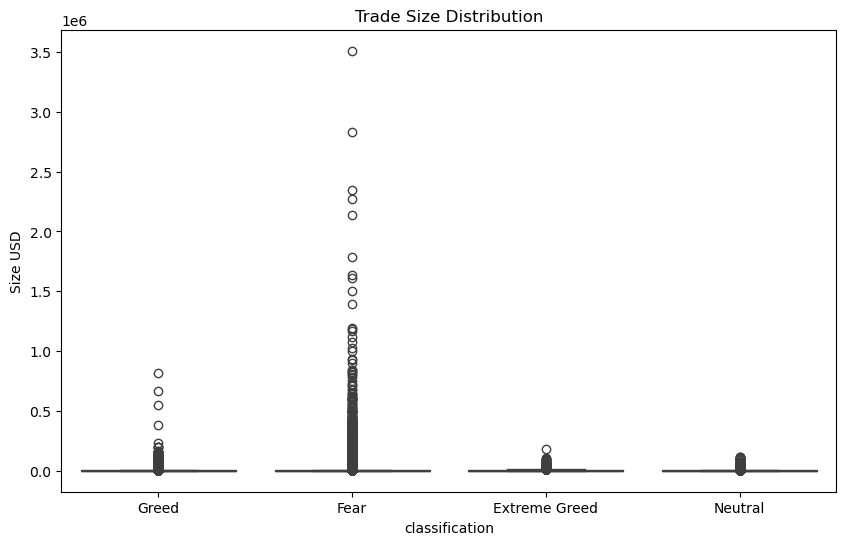

In [107]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Trade Size Distribution")

plt.savefig(
    "charts/trade_size_distribution.png"
)

plt.show()

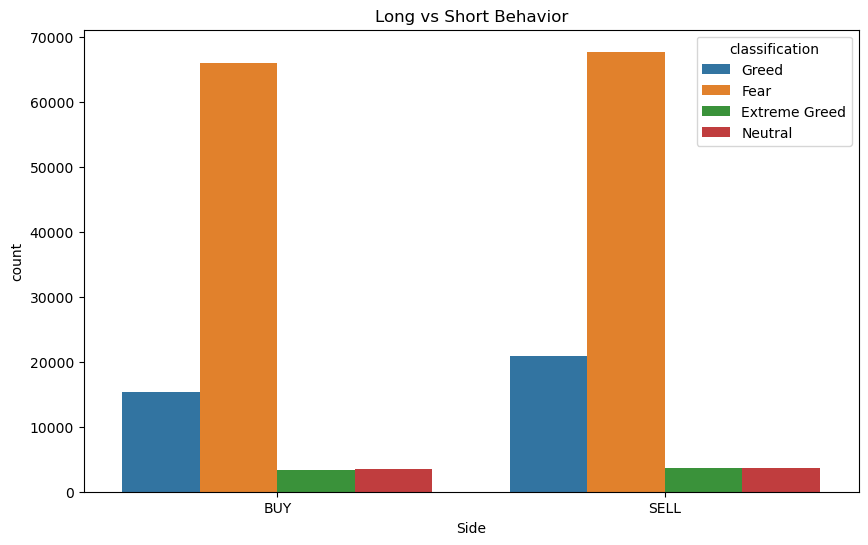

In [108]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Side',
    hue='classification',
    data=merged
)

plt.title("Long vs Short Behavior")

plt.savefig(
    "charts/long_short_behavior.png"
)

plt.show()

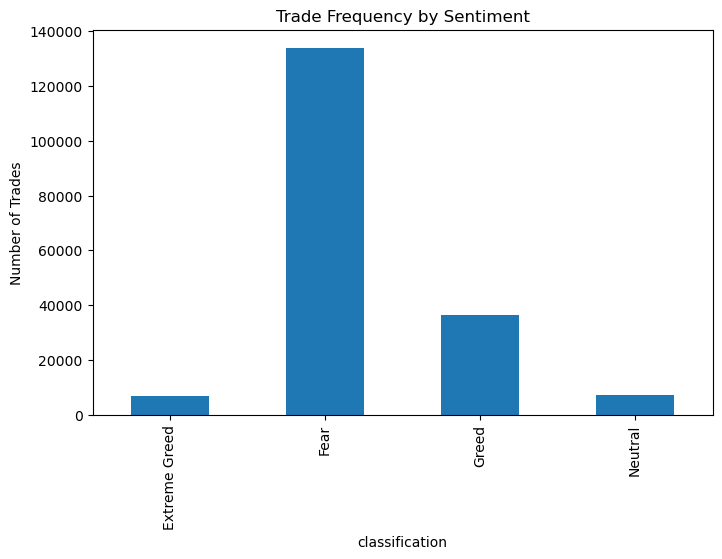

In [109]:
trade_frequency = merged.groupby(
    'classification'
).size()

plt.figure(figsize=(8,5))

trade_frequency.plot(kind='bar')

plt.title("Trade Frequency by Sentiment")

plt.ylabel("Number of Trades")

plt.savefig(
    "charts/trade_frequency.png"
)

plt.show()

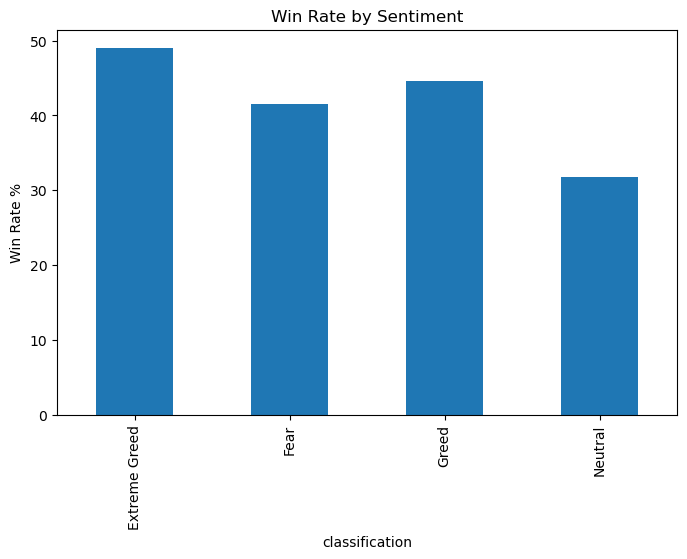

In [110]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title("Win Rate by Sentiment")

plt.ylabel("Win Rate %")

plt.savefig(
    "charts/win_rate.png"
)

plt.show()

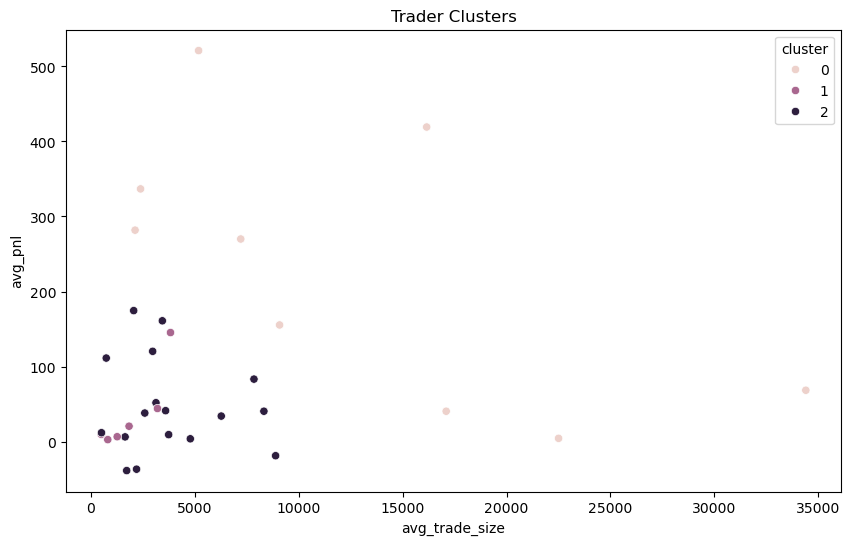

In [111]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='avg_trade_size',
    y='avg_pnl',
    hue='cluster',
    data=trader_features
)

plt.title("Trader Clusters")

plt.savefig(
    "charts/trader_clusters.png"
)

plt.show()